# PHÁT HIỆN DỊ THƯỜNG TRONG DỮ LIỆU CHUỖI THỜI GIAN COVID-19

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src/time-series'))
sys.path.append(os.path.abspath('../src'))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from dataset import TimeSeriesDataset
from preprocessing_detect_outlier import DetectOutlierTimeSeries
from visualization.comparison import plot_anomalies_all_methods

warnings.filterwarnings('ignore')

## 1. Cơ sở lý thuyết
### 1.1. Thế nào là điểm bất thường trong dữ liệu Covid-19?
Trong chuỗi thời gian Covid-19 (ví dụ như số ca nhiễm mới hàng ngày), **điểm bất thường (Anomaly/Outlier)** là những quan sát lệch khỏi quy luật vận động tự nhiên của dịch bệnh hoặc quy trình báo cáo y tế.
- **Dị thường do lỗi hệ thống (Data Dumping):** Do việc dồn báo cáo từ nhiều ngày vào một ngày duy nhất (thường thấy vào đầu tuần), tạo ra các cột dữ liệu cao đột biến không phản ánh đúng tốc độ lây nhiễm thực tế.
- **Dị thường do biến cố thực tế:** Sự xuất hiện của một biến chủng mới hoặc một sự kiện siêu lây nhiễm khiến số ca tăng vọt ra ngoài xu hướng hiện tại.
- **Dị thường do bối cảnh (Contextual):** Một ngày có 500 ca nhiễm là bình thường nếu đang ở đỉnh dịch, nhưng là dị thường nếu dịch đang trong giai đoạn kiểm soát tốt.

### 1.2. Dùng Z-score trên dữ liệu Deseasonalized
Ở đây, dữ liệu Covid-19 có tính chu kỳ tuần (Weekly Seasonality) rất mạnh: số ca báo cáo vào cuối tuần thường thấp và tăng vọt vào thứ Hai/thứ Ba do độ trễ hành chính.

Vấn đề có thể xảy ra khi dùng Z-score ($Z = \frac{x - \mu}{\sigma}$) trực tiếp trên dữ liệu gốc, vì khi đó các ngày thứ Hai thường xuyên bị đánh dấu là dị thường vì chúng luôn cao hơn trung bình, dù đó chỉ là quy luật hàng tuần.

Vì vậy, dữ liệu cần được **loại bỏ đi tính mùa vụ (Deseasonalized)** để Z-score có thể phát hiện được điểm bất thường, cụ thể: 
- Khi loại bỏ tính mùa vụ, ta **lấy dữ liệu gốc trừ đi thành phần chu kỳ ($Y_t - S_t$)**, và thu được thành phần dư thừa (Residual/Noise).
- Từ đó, khi tính Z-score áp dụng trên Residual trên chuỗi đã khử chu kỳ này, ta đang so sánh sự biến động của ngày hôm đó với mức nền thực tế (đã loại bỏ nhiễu hành chính), và khi đó thực sự phản ánh một sự biến động bất thường về dịch tễ hoặc lỗi nhập liệu nghiêm trọng, chứ không phải do hiệu ứng "ngày thứ Hai" như đã đề cập. Với điểm có $|Z| > threshold$ (thường là 3), điểm đó sẽ được coi là dị thường.

### 1.3. Các bước phát hiện dị thường của Isolation Forest
Isolation Forest sẽ tập trung vào việc cô lập điểm dữ liệu.

**Các bước thực hiện:**
- **Lấy mẫu ngẫu nhiên (Sampling)**: Chọn một tập con dữ liệu từ cửa sổ thời gian của chuỗi Covid-19.
- **Phân tách nhị phân (Random Splitting)**:
  * Chọn ngẫu nhiên một đặc trưng (ví dụ: New_cases).
  * Chọn ngẫu nhiên một giá trị cắt giữa Min và Max của đặc trưng đó.
- **Xây dựng cây cô lập (iTree)**: Lặp lại việc chia tách cho đến khi điểm dữ liệu hoàn toàn bị cô lập trong một nút lá.
- **Đánh giá độ dài đường đi (Path Length)**:
  * Điểm dị thường (số ca quá cao hoặc quá thấp) thường nằm xa đám đông nên dễ bị cô lập hơn $\rightarrow$ Đường đi từ gốc đến lá **ngắn**.
  * Điểm bình thường nằm cụm với nhau $\rightarrow$ Cần nhiều lần cắt mới cô lập được $\rightarrow$ Đường đi **dài**.
- **Tính Anomaly Score**: Kết hợp kết quả từ nhiều cây để đưa ra xác suất dị thường.

### 1.4. Các bước phát hiện dị thường dựa trên STL Residual Thresholding
Phương pháp này dựa trên việc phân rã chuỗi thời gian để tìm ra những sai số không thể giải thích được bằng quy luật.

**Các bước thực hiện:**
- **Phân rã STL (Seasonal-Trend decomposition using LOESS):** Tách chuỗi gốc $Y_t$ thành 3 thành phần:
  $$Y_t = T_t (\text{Trend}) + S_t (\text{Seasonality}) + R_t (\text{Residual})$$

- **Trích xuất Residual:** Tập trung hoàn toàn vào thành phần $R_t$ (phần dư). Đây là nơi chứa đựng các nhiễu trắng và các biến động bất thường.
- **Tính toán ngưỡng (Thresholding):** Xác định ngưỡng biên cho $R_t$ bằng các phương pháp thống kê:
  * Ngưỡng $3\sigma$: $[\mu - 3\sigma, \mu + 3\sigma]$.
  * Ngưỡng IQR: Sử dụng khoảng cách liên tứ phân vị để xác định các điểm nằm ngoài whisker của biểu đồ hộp Boxplot.
- **Đánh dấu dị thường:** Bất kỳ thời điểm $t$ nào có $|R_t|$ vượt ra ngoài ngưỡng đã thiết lập sẽ được gắn nhãn là điểm dị thường.

Đối với dữ liệu Covid-19, phương pháp **STL** thường ổn định hơn **Z-score** vì nó xử lý tốt cả **Xu hướng (Trend)** đang tăng nhanh và **Chu kỳ (Seasonality)** lặp lại, giúp việc phát hiện dị thường không bị lệch theo độ dốc của biểu đồ.

## 2. Phân tích và nhận xét
### 2.1. Định hình bài toán và dữ liệu
Chúng ta sẽ xác định xem các điểm bất thường trong dữ liệu Covid-19 là do biến cố dịch tễ thực tế (bùng dịch, nới lỏng giãn cách) hay chỉ là nhiễu dữ liệu (dồn báo cáo cuối tuần, điều chỉnh lại số liệu).

**Về phạm vi dữ liệu:** 

- **Biến phân tích (Target Variables):** Lựa chọn phân tích số ca mắc mới (`New_cases`) và số ca tử vong mới (`New_deaths`). Lý do: Dữ liệu tích lũy (`Confirmed`, `Deaths`) mang tính chất chuỗi không dừng (Non-stationary) và có xu hướng tăng liên tục, rất khó để các thuật toán bắt được sự đột biến cục bộ. Việc lấy sai phân để tìm số ca mới mỗi ngày là bắt buộc.

- **Khu vực lựa chọn (Countries of Interest):** Để so sánh độ hiệu quả của thuật toán trên các hình thái phân phối khác nhau, ta chọn 4 quốc gia đại diện:
  + **US (Mỹ):** Khối lượng dữ liệu khổng lồ, bùng phát nhiều làn sóng rõ rệt.
  + **Italy (Ý):** Tâm dịch đầu tiên tại Châu Âu, thể hiện sự hoảng loạn dữ liệu giai đoạn đầu.
  + **Vietnam (Việt Nam):** Điển hình cho nhóm kiểm soát cực tốt giai đoạn đầu nhưng bùng nổ mạnh ở giai đoạn sau (Delta wave).
  + **Brazil:** Nổi tiếng với nhiều vấn đề trong khâu ghi nhận và báo cáo dữ liệu y tế, kỳ vọng sẽ có nhiều dữ liệu nhiễu.

In [3]:
TARGET_COUNTRIES = ['US', 'Italy', 'Vietnam', 'Brazil']
DATA_PATH = '../data/time-series/time-series-19-covid-combined.csv' 

In [4]:
# Load dữ liệu 
try:
    df_raw = pd.read_csv(DATA_PATH)
    if 'Country/Region' in df_raw.columns:
        df_raw.rename(columns={'Country/Region': 'Country'}, inplace=True)
    if 'ObservationDate' in df_raw.columns:
        df_raw.rename(columns={'ObservationDate': 'Date'}, inplace=True)
        
    df_raw['Date'] = pd.to_datetime(df_raw['Date'])
    print(f"Tổng số bản ghi ban đầu: {len(df_raw)}")
except Exception as e:
    print(f"[LỖI] Không thể tải dữ liệu: {e}")

Tổng số bản ghi ban đầu: 72090


Dữ liệu nguyên bản thường lưu trữ dạng cộng dồn (Cumulative). Ta sẽ thực hiện một hàm tiền xử lý với các bước sau:
- **Gộp dữ liệu (Aggregation):** Nhiều quốc gia (như Mỹ) được chia nhỏ thành các bang/tỉnh. Ta cần `groupby` theo Ngày và Quốc gia để lấy tổng số ca toàn quốc.
- **Lấy sai phân (Differencing):** Ta sẽ dùng hàm `.diff()` để tính số ca mắc/tử vong mới mỗi ngày.
- **Làm sạch nhiễu kỹ thuật (Data Cleaning):** Trong thực tế thống kê y tế, đôi khi các quốc gia thanh tra lại dữ liệu và trừ đi số ca khai khống trước đó, dẫn đến việc sai phân bị âm. Mặc dù đây là một dạng dị thường, nhưng nó là lỗi logic toán học. Ta sẽ giới hạn các giá trị âm về 0 hoặc nội suy bằng `bfill/ffill`.

In [5]:
def prepare_daily_data(df, countries):
    """Hàm trích xuất số ca mới hàng ngày từ dữ liệu tích lũy."""
    df_filtered = df[df['Country'].isin(countries)].copy()
    
    # Gộp tổng số liệu các tỉnh/bang thành số liệu cấp quốc gia theo ngày
    df_grouped = df_filtered.groupby(['Country', 'Date'])[['Confirmed', 'Deaths']].sum().reset_index()
    df_grouped = df_grouped.sort_values(by=['Country', 'Date'])
    
    # Tính sai phân (Daily New Cases/Deaths)
    df_grouped['New_cases'] = df_grouped.groupby('Country')['Confirmed'].diff().fillna(0)
    df_grouped['New_deaths'] = df_grouped.groupby('Country')['Deaths'].diff().fillna(0)
    
    # Xử lý các giá trị âm (Lỗi báo cáo y tế)
    negative_cases = len(df_grouped[df_grouped['New_cases'] < 0])
    print(f"[INFO] Phát hiện và xử lý {negative_cases} ngày có số ca mắc mới bị âm (Data Correction).")
    
    df_grouped['New_cases'] = df_grouped['New_cases'].clip(lower=0)
    df_grouped['New_deaths'] = df_grouped['New_deaths'].clip(lower=0)
    
    return df_grouped

Tiến hành thực thi trích xuất

In [6]:
# Thực thi trích xuất
df_daily = prepare_daily_data(df_raw, TARGET_COUNTRIES)
display(df_daily.tail())

[INFO] Phát hiện và xử lý 1 ngày có số ca mắc mới bị âm (Data Correction).


,Country,Date,Confirmed,Deaths,New_cases,New_deaths
1075,Vietnam,2020-10-13,1113,35,3.0,0.0
1076,Vietnam,2020-10-14,1122,35,9.0,0.0
1077,Vietnam,2020-10-15,1124,35,2.0,0.0
1078,Vietnam,2020-10-16,1124,35,0.0,0.0
1079,Vietnam,2020-10-17,1126,35,2.0,0.0


Trước khi đi vào phân tích sâu hơn, ta sẽ vẽ biểu đồ chuỗi thời gian cho biến `New_cases` của 4 quốc gia đã chọn.

In [7]:
def plot_baseline_scoping(df, countries, target_col='New_cases'):
    """Vẽ biểu đồ chuỗi thời gian tổng quan để nhận diện hình thái dữ liệu."""
    plt.figure(figsize=(16, 10))
    
    for i, country in enumerate(countries, 1):
        plt.subplot(2, 2, i)
        df_country = df[df['Country'] == country]
        
        plt.plot(df_country['Date'], df_country[target_col], 
                 color='steelblue', linewidth=1.5, alpha=0.8)
        
        plt.title(f'{country} - Daily {target_col}', fontsize=12, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Count')
        plt.grid(True, linestyle='--', alpha=0.5)
        
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

Tiến hành trực quan hoá

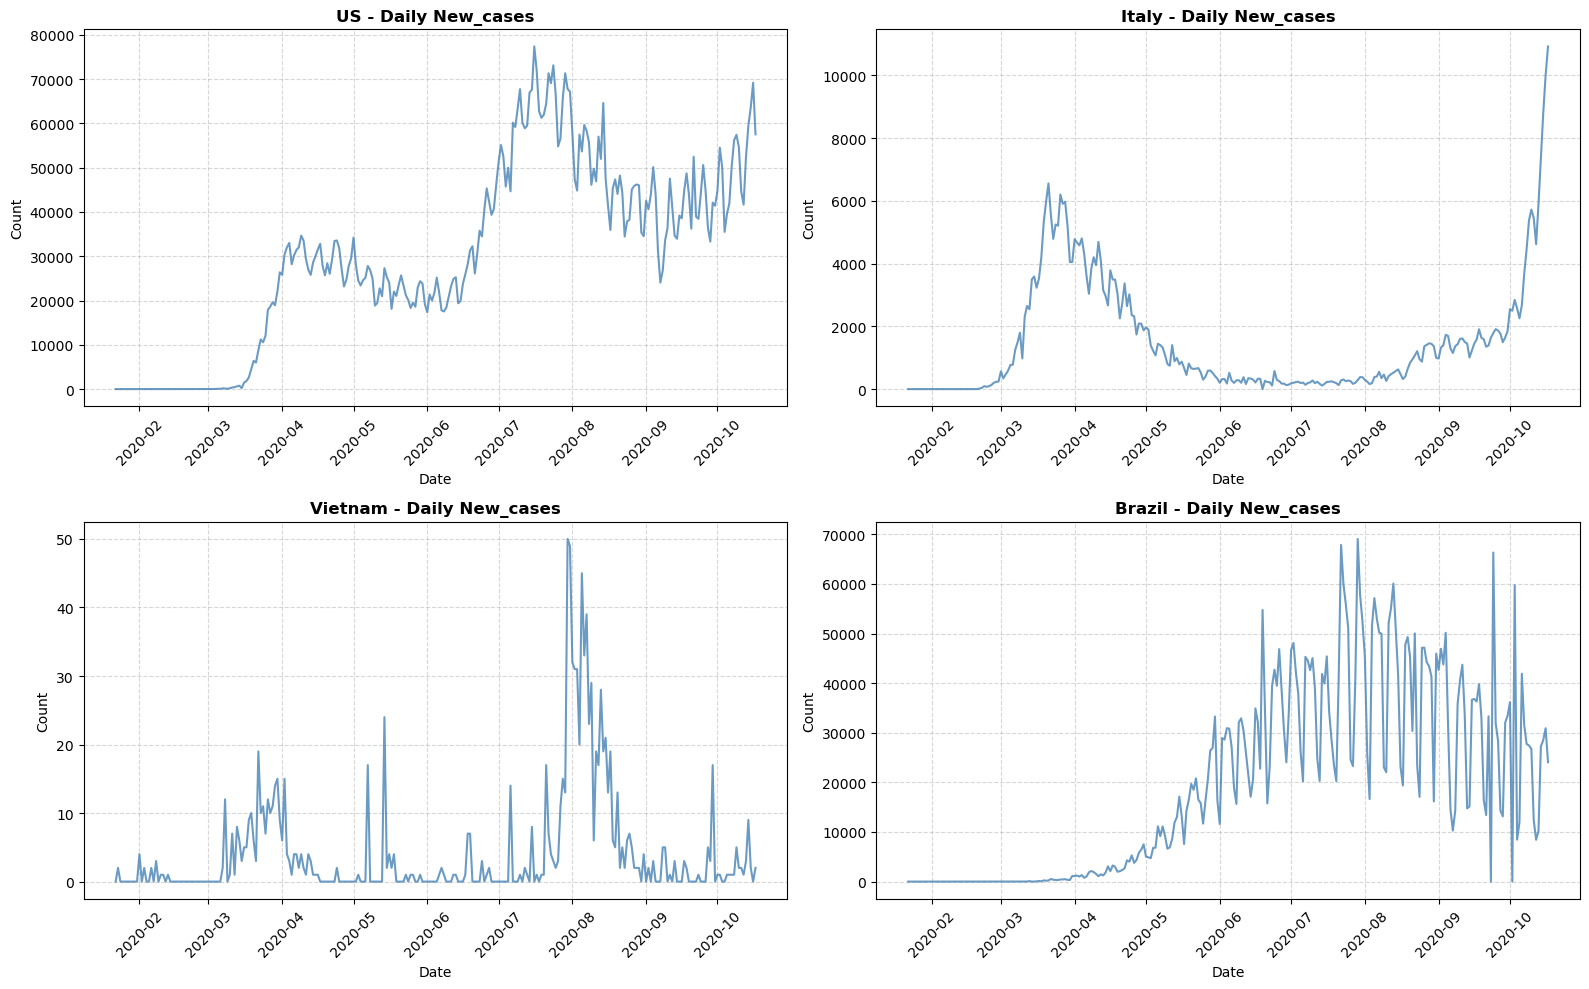

In [8]:
plot_baseline_scoping(df_daily, TARGET_COUNTRIES, target_col='New_cases')

Biểu đồ này phản ánh cực kỳ rõ nét đặc thù dữ liệu của 4 khu vực trong giai đoạn từ đầu năm 2020 đến khoảng tháng 10/2020. Cụ thể:
- Phân tích chi tiết từng quốc gia
    + Đường biểu diễn của **Mỹ** dao động với biên độ lớn theo hình răng cưa liên tục. Đây là minh chứng rõ nhất cho tính chu kỳ tuần (Weekly Seasonality) do độ trễ báo cáo (cuối tuần số ca giảm sâu, thứ 2/thứ 3 tăng vọt).
    + Đường biểu diễn của **Ý** thể hiện cấu trúc dịch tễ rất rõ ràng với 2 làn sóng: Làn sóng 1 vào tháng 3/tháng 4 và Làn sóng 2 với đợt bùng phát mạnh bắt đầu từ tháng 10. Giai đoạn giữa (tháng 6 - tháng 8) thì dữ liệu không có nhiều biến động đáng kể. Với dạng dữ liệu có xu hướng thay đổi đột ngột như thế này, phương pháp phân rã cấu trúc (STL) sẽ hoạt động cực kỳ hiệu quả để bắt được những ngày bùng dịch thực sự.
    + Biểu đồ của **Việt Nam** gần như là một đường thẳng bám sát trục hoành (0 ca), chỉ có những gợn sóng cực nhỏ (chỉ khoảng vài chục ca trong đợt dịch Đà Nẵng tháng 7/2020). Vì biểu đồ dùng chung tỷ lệ trục tung (hoặc tỷ lệ quá lớn so với số ca của VN) nên đường line bị ép dẹt.Có thể thấy, dữ liệu có phương sai cực thấp. Đối với VN trong năm 2020, một ngày có 50 ca mắc mới về mặt toán học đã là một điểm dị thường khổng lồ so với mức trung bình gần bằng 0. Thuật toán có độ nhạy cao sẽ vạch ra rất nhiều dị thường ở đoạn này.
    + Còn với **Brazil**, sau giai đoạn tăng dốc, số ca duy trì ở mức đỉnh nhưng dao động cực kỳ mạnh (từ 20.000 có thể giật lên 60.000 rồi rớt xuống ngay hôm sau). Nhìn vào khoảng đen đặc trên biểu đồ, có thể thấy dữ liệu rất bẩn (Data Dumping - dấu hiệu của việc dồn báo cáo). Isolation Forest sẽ là lựa chọn tiềm năng nhất ở biểu đồ này vì nó cô lập những điểm giật cục này rất tốt.
- Tổng kết lại, ta thấy dữ liệu có tính chất **non-stationary** rõ rệt: Dù đã lấy sai phân (`New Cases`), ta vẫn thấy rõ kỳ vọng và phương sai thay đổi liên tục theo thời gian ở Mỹ, Ý và Brazil. Ngoài ra, nhìn vào sự khác biệt giữa Mỹ (biến động hàng chục ngàn ca) và Việt Nam (biến động vài chục ca), ta không thể dùng một ngưỡng tĩnh cố định (như số ca > 10.000 là bất thường) cho tất cả các nước. Ta bắt buộc phải dùng các phương pháp mang tính tương đối (như Z-score chuẩn hóa, Thresholding dựa trên IQR, hoặc Cây cô lập) để khi phân tích cho mỗi quốc gia có thể tự đưa ra ngưỡng dị thường của riêng mình.

### 2.2. Tối ưu hoá tham số cửa sổ trượt (Window Size) cho từng quốc gia
Thuật toán **Isolation Forest** mà chúng ta áp dụng sẽ phát hiện dị thường dựa trên việc so sánh một điểm dữ liệu với các điểm lân cận trong một cửa sổ trượt (Sliding Window - $W$). Cửa sổ quy định như sau:
- $W = 3$: Tầm nhìn cực ngắn, nhạy cảm với các nhiễu nhỏ nhất.
- $W = 7$: Tầm nhìn chu kỳ tuần, phù hợp với nhịp độ báo cáo hành chính.
- $W = 14$: Tầm nhìn theo chu kỳ ủ bệnh/lây nhiễm của Covid-19.
- $W = 30$: Tầm nhìn theo xu hướng vĩ mô của tháng.

Vậy nên, chúng ta sẽ chạy thuật toán **Isolation Forest** với mức độ ô nhiễm cố định là 5% trên 4 quốc gia: **US**, **Italy**, **Vietnam**, **Brazil**. Với mỗi quốc gia, ta thử nghiệm cả 4 kích thước cửa sổ trên. Cuối cùng, ta lập bảng thống kê số lượng điểm dị thường phát hiện được để đánh giá độ nhạy và độ ổn định của từng tham số đối với từng hình thái dịch tễ.

Đầu tiên là thiết lập tham số và môi trường lưu trữ kết quả, chúng ta sẽ khai báo danh sách các cửa sổ cần test và danh sách các quốc gia. Đồng thời, tạo một dictionary hai chiều để lưu lại các `anomaly_mask` phục vụ cho việc đối chiếu và trực quan hóa sau này.

In [9]:
# Cấu hình tham số Tuning
windows_to_test = [3, 7, 14, 30]

countries = ['US', 'Italy', 'Vietnam', 'Brazil']

# Khởi tạo nơi lưu trữ kết quả
summary_results = []
tuning_masks_dict = {country: {} for country in countries} 

Ở bước này, chúng ta sẽ lặp qua từng quốc gia và từng kích thước cửa sổ. Với mỗi cấu hình:
- Đẩy dữ liệu vào `TimeSeriesDataset`.
- Khởi tạo `DetectOutlierTimeSeries` với `window_size` tương ứng. Tỷ lệ dị thường được giữ cố định ở 5% để đảm bảo tính công bằng.
- Cho dataset gọi hàm `accept(detector)` để chạy qua pipeline.
- Thu thập số lượng điểm dị thường và gán vào list.

In [10]:
for country in countries:
    df_country = df_daily[df_daily['Country'] == country].copy()
    
    dataset_tuning = TimeSeriesDataset(path=None, time_column='Date')
    dataset_tuning.data = df_country
    dataset_tuning.set_target(target_column='New_cases')
    
    for w in windows_to_test:
        detector = DetectOutlierTimeSeries(method='iforest', window_size=w, contamination=0.05)

        old_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w') 
        try:
            dataset_tuning.accept(detector)
            mask = detector.get_anomaly_mask()
        finally:
            sys.stdout = old_stdout 
            
        num_anomalies = mask.sum()
        tuning_masks_dict[country][f'Window_{w}'] = mask
        
        summary_results.append({
            'Country': country,
            'Window_Size': f'W = {w}',
            'Anomalies_Count': num_anomalies
        })

Để dễ dàng trả lời câu hỏi "độ ổn định của số lượng dị thường trên từng quốc gia", ta sẽ biến đổi danh sách kết quả thành một Pivot Table.

Bảng này giúp ta nhìn theo chiều ngang (theo từng quốc gia) xem khi cửa sổ $W$ tăng dần, số lượng điểm bị bắt lại có thay đổi quá giật cục không hay giữ được sự nhất quán.

In [11]:
df_summary = pd.DataFrame(summary_results)

pivot_table = df_summary.pivot(index='Country', columns='Window_Size', values='Anomalies_Count')

pivot_table = pivot_table[['W = 3', 'W = 7', 'W = 14', 'W = 30']]

print("BẢNG TỔNG HỢP SỐ LƯỢNG ĐIỂM DỊ THƯỜNG THEO WINDOW SIZE")
print("="*60)
display(pivot_table)

BẢNG TỔNG HỢP SỐ LƯỢNG ĐIỂM DỊ THƯỜNG THEO WINDOW SIZE


Window_Size,W = 3,W = 7,W = 14,W = 30
Country,,,,
Brazil,14,14,14,14
Italy,14,14,14,14
US,14,14,14,14
Vietnam,14,14,14,14


Cuối cùng là trực quan hóa đối chiếu các Window Size với nhau. Ở đây, ta chọn Brazil làm minh họa vì trước đó chúng ta đã nhận xét nước này có hiện tượng dồn các báo cáo giật cục cực kỳ phức tạp.

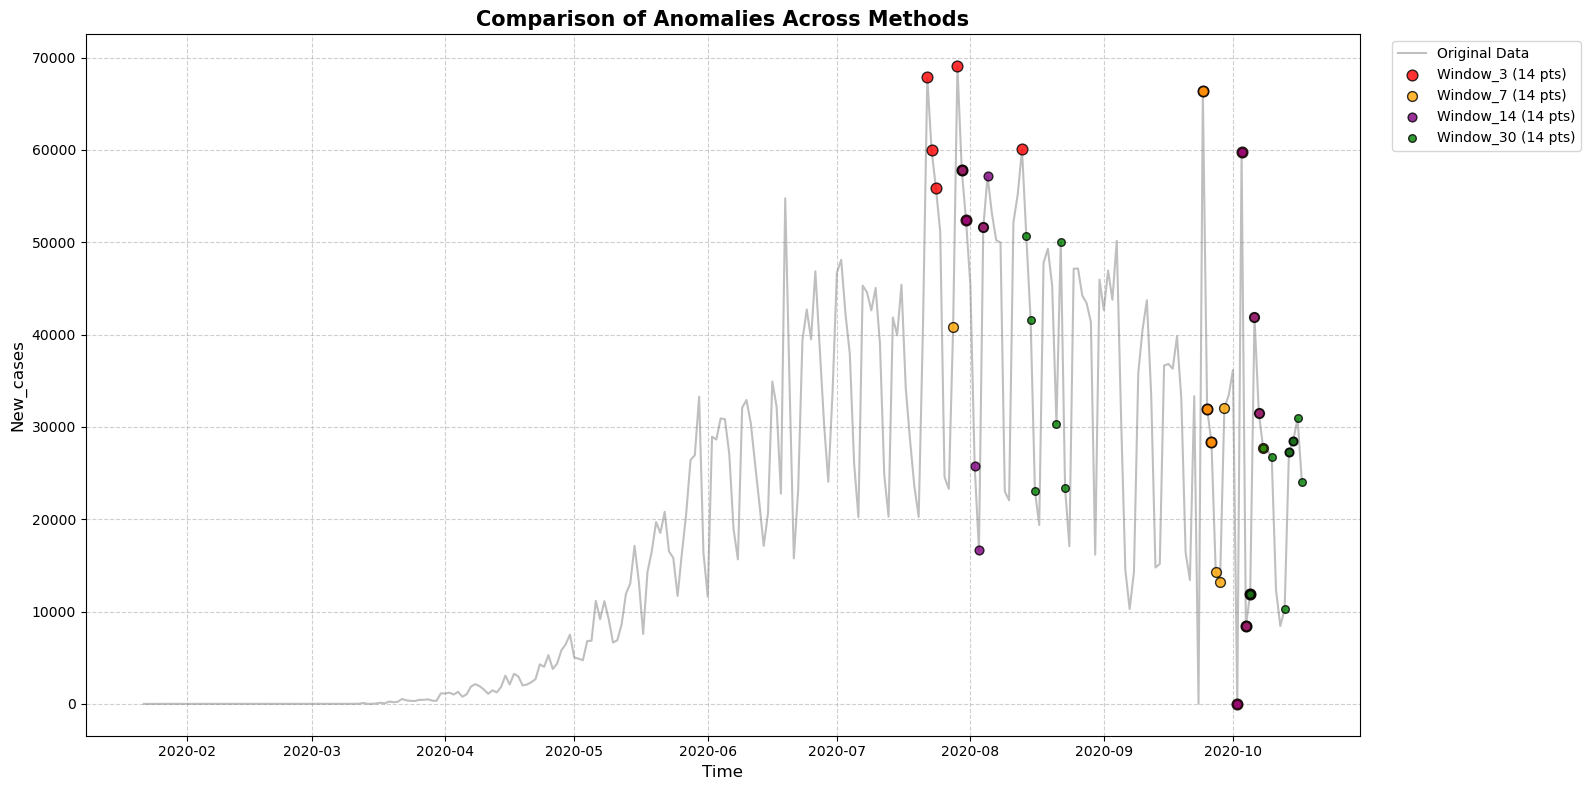

In [12]:
demo_country = 'Brazil'

df_demo = df_daily[df_daily['Country'] == demo_country].copy()
dataset_demo = TimeSeriesDataset(path=None, time_column='Date')
dataset_demo.data = df_demo
dataset_demo.set_target(target_column='New_cases')

try:
    plot_anomalies_all_methods(dataset=dataset_demo, anomalies_dict=tuning_masks_dict[demo_country])
except Exception as e:
    print(f"[ERROR] Failed to plot the graph: {e}")

Khi quan sát sự dịch chuyển vị trí của 14 điểm dị thường này trên biểu đồ khi $W$ thay đổi, ta có thể đánh giá như sau:
- Với $W = 3$ (Ngắn hạn): Cửa sổ quá hẹp (chỉ nhìn lại 2 ngày trước). Thuật toán trở nên quá nhạy cảm và thường xuyên bị đánh lừa bởi những dao động nhiễu cực nhỏ mang tính ngẫu nhiên của ngày hôm trước so với ngày hôm sau.
- Với $W = 7$ (Chu kỳ tuần): Đây là tầm nhìn phản ánh chính xác nhịp độ hành chính của hệ thống y tế thế giới (nghỉ cuối tuần, dồn số liệu vào đầu tuần). Tại Brazil và Mỹ, $W=7$ bắt thành công các đỉnh giật cục hình răng cưa khổng lồ do hiện tượng Data Dumping (dồn báo cáo).
- Với $W = 14$ (Chu kỳ ủ bệnh): Tầm nhìn này bắt đầu làm mượt các nhiễu hành chính và nhạy cảm hơn với các điểm chuyển pha dịch tễ (ví dụ: ngày bắt đầu bùng phát một làn sóng mới).
- Với $W = 30$ (Xu hướng tháng): Cửa sổ quá rộng. Dữ liệu bị trung bình hóa quá nhiều khiến Isolation Forest gặp khó khăn trong việc nhận diện các cú sốc cục bộ (những ngày nổ ca đột biến).

Vì vậy, kích thước cửa sổ $W = 7$ sẽ **là sự lựa chọn phù hợp và đáng tin cậy nhất** để bám sát đặc thù dữ liệu y tế. Nó vừa đủ ngắn để giữ lại độ nhạy với các ca nhiễm mới, vừa đủ dài để bao hàm hiệu ứng chu kỳ làm việc 7 ngày của con người, qua đó đánh dấu chính xác các bất thường mang tính hệ thống.

### 2.3. Đánh giá độ tin cậy của các phương pháp
Xét trên 3 thuật toán: **Z-score**, **Isolation Forest** và **STL Residual Thresholding**, chúng ta sẽ tập trung giải quyết các câu hỏi chính:
- Hình thái của STL có bám sát các làn sóng bùng phát dịch không?
- Thuật toán nào dễ bị đánh lừa bởi hiệu tượng dồn báo cáo cuối tuần nhất?

Để kiểm tra xoay quanh hiện tượng dồn báo cáo cuối tuần, chúng ta sẽ chọn **US (Mỹ)** làm quốc gia minh họa chính. Ở các phân tích ban đầu, ta đã thấy Mỹ có biểu đồ răng cưa cực kỳ rõ rệt do việc dồn báo cáo y tế từ Chủ Nhật sang Thứ Hai / Thứ Ba.

In [13]:
benchmark_country = 'US'

df_benchmark = df_daily[df_daily['Country'] == benchmark_country].copy()

dataset_benchmark = TimeSeriesDataset(path=None, time_column='Date')
dataset_benchmark.data = df_benchmark
dataset_benchmark.set_target(target_column='New_cases')

(    Country       Date  Confirmed  Deaths  New_deaths
 540      US 2020-01-22          1       0         0.0
 541      US 2020-01-23          1       0         0.0
 542      US 2020-01-24          2       0         0.0
 543      US 2020-01-25          2       0         0.0
 544      US 2020-01-26          5       0         0.0
 ..      ...        ...        ...     ...         ...
 805      US 2020-10-13    7856605  215887       802.0
 806      US 2020-10-14    7916099  216872       985.0
 807      US 2020-10-15    7979709  217692       820.0
 808      US 2020-10-16    8048865  218575       883.0
 809      US 2020-10-17    8106384  219286       711.0
 
 [270 rows x 5 columns],
 540        0.0
 541        0.0
 542        1.0
 543        0.0
 544        3.0
         ...   
 805    52406.0
 806    59494.0
 807    63610.0
 808    69156.0
 809    57519.0
 Name: New_cases, Length: 270, dtype: float64)

Ta sẽ chạy vòng lặp qua 3 phương pháp **Z-score**, **Isolation Forest** và **STL Residual Thresholding**. Tất cả đều được thiết lập với tham số $W = 7$ để đảm bảo tính công bằng. Kết quả (Boolean Mask) của mỗi phương pháp sẽ được lưu lại để đối chiếu.

In [14]:
# Các phương pháp cần so sánh
methods = ['z-score', 'iforest', 'stl']
benchmark_masks = {}
anomalies_indices = {}

In [15]:
for method in methods:
    detector = DetectOutlierTimeSeries(method=method, window_size=7, contamination=0.05)
    
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w') 
    try:
        dataset_benchmark.accept(detector)
        mask = detector.get_anomaly_mask()
        indices = detector.get_anomaly_candidates()
    finally:
        sys.stdout = old_stdout
        
    benchmark_masks[method.upper()] = mask
    anomalies_indices[method.upper()] = indices
    
    print(f"[*] Phương pháp {method.upper():<10} | Phát hiện: {mask.sum():>3} điểm dị thường")

[*] Phương pháp Z-SCORE    | Phát hiện:   0 điểm dị thường
[*] Phương pháp IFOREST    | Phát hiện:  14 điểm dị thường
[*] Phương pháp STL        | Phát hiện:  39 điểm dị thường


Sau đó là biểu diễn cả 3 phương pháp lên cùng một đồ thị để trực quan hóa sự giao thoa.

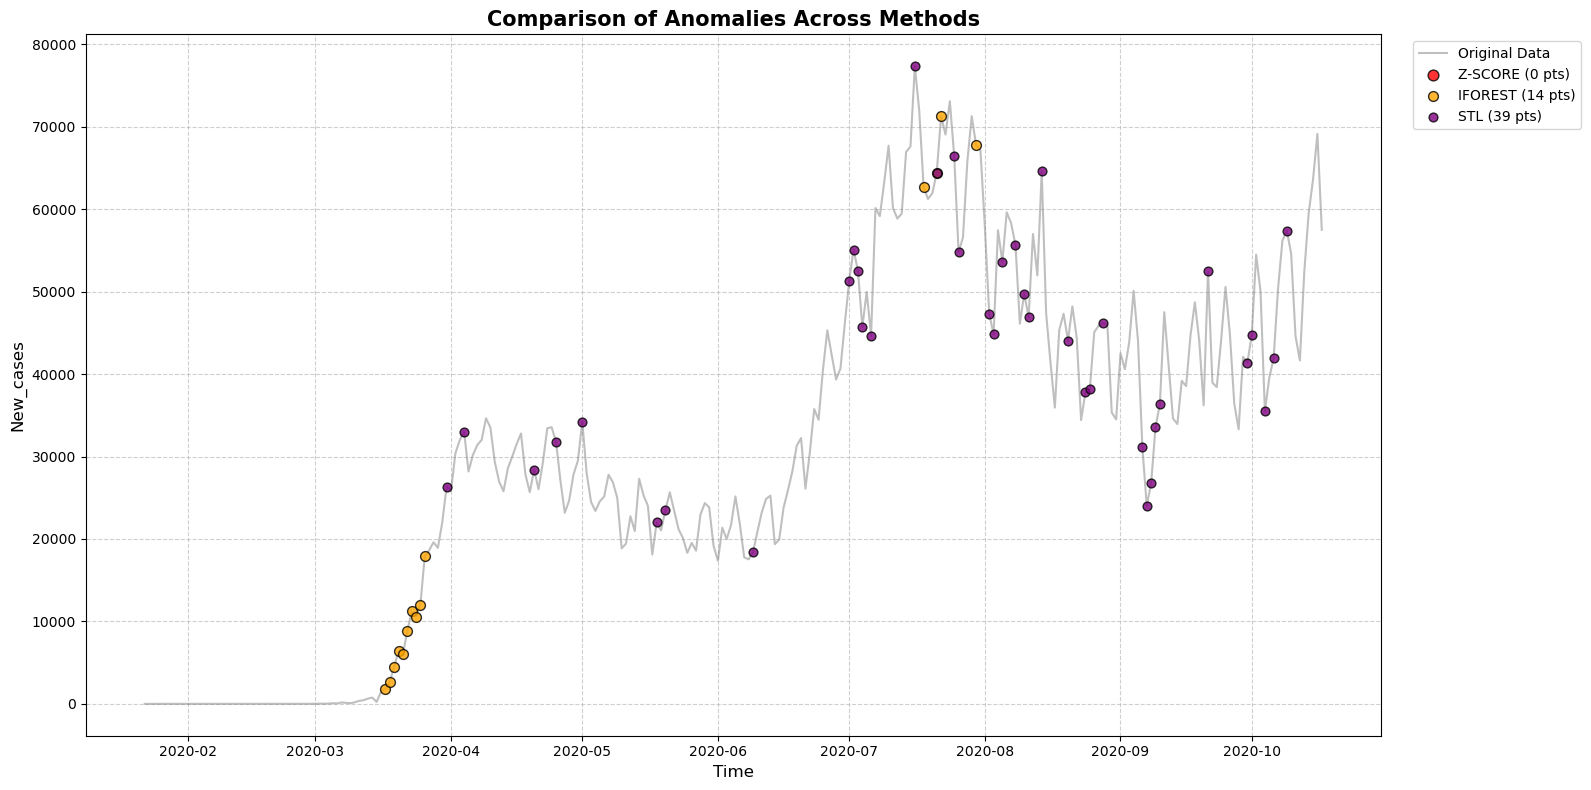

In [16]:
try:
    plot_anomalies_all_methods(dataset=dataset_benchmark, anomalies_dict=benchmark_masks)
except Exception as e:
    print(f"[LỖI] Không thể vẽ biểu đồ: {e}")

Ta còn tiến hành chấm điểm độ tin cậy (Kiểm định Hiệu ứng báo cáo cuối tuần) với cách đánh giá như sau: Nếu một điểm dị thường là do bùng dịch thật, nó có thể xảy ra vào bất kỳ ngày nào trong tuần. Nếu một phương pháp bắt được dị thường mà có tới >50% số điểm đó rơi vào Thứ 2 hoặc Thứ 3 (những ngày xử lý số liệu tồn đọng cuối tuần), thì phương pháp đó đang bị báo động giả (False Positives) bởi nhiễu hành chính.

In [17]:
dates_series = dataset_benchmark.data['Date']

reliability_scores = []

for method_name, mask in benchmark_masks.items():
    anomaly_dates = dates_series[mask]
    
    days_of_week = anomaly_dates.dt.dayofweek
    
    mon_tue_count = sum(days_of_week.isin([0, 1]))
    total_anomalies = len(anomaly_dates)
    
    if total_anomalies > 0:
        false_positive_rate = (mon_tue_count / total_anomalies) * 100
    else:
        false_positive_rate = 0.0
        
    reliability_scores.append({
        'Method': method_name,
        'Total Anomalies': total_anomalies,
        'Anomalies on Mon/Tue': mon_tue_count,
        'Weekend Effect Bias (%)': round(false_positive_rate, 2)
    })

df_reliability = pd.DataFrame(reliability_scores)

df_reliability = df_reliability.sort_values(by='Weekend Effect Bias (%)')
display(df_reliability)

,Method,Total Anomalies,Anomalies on Mon/Tue,Weekend Effect Bias (%)
0,Z-SCORE,0,0,0.00
1,IFOREST,14,4,28.57
2,STL,39,15,38.46


Các kết quả thu được cho thấy: 
- Phân tích **Z-Score** không phát hiện điểm dị thường nào, nên dĩ nhiên tỷ lệ nhiễu rơi vào hiện tượng dồn báo cáo cuối tuần cũng là 0.00%. Có thể thấy **Z-score** (áp dụng trên dữ liệu đã deseasonalize) với thiết lập `Threshold = 3.0` trong một cửa sổ trượt ngắn (7 ngày) trên một chuỗi dữ liệu có phương sai biến động quá mạnh như Mỹ đã khiến không một điểm nào đủ sức vượt qua ngưỡng. Điều này thể hiện rằng **Z-score** mặc dù có thể né được 100% các dị thường giả (do hiện tượng dồn báo cáo cuối tuần), nhưng cái giá phải trả là nó bỏ lỡ luôn (False Negatives) toàn bộ các đợt bùng dịch thực sự. Vậy nên, **Z-score** hoàn toàn thất bại ở cấu hình này.
- Phân tích **Isolation Forest** với 14 điểm dị thường được phát hiện, trong đó tỷ lệ nhiễu rơi vào hiện tượng dồn báo cáo cuối tuần là 28.57%. Tỉ lệ này vừa hay lại trùng với xác suất một ngày trong tuần rơi vào Thứ Hai hoặc Thứ Ba. Điều này chứng tỏ **Isolation Forest** hoàn toàn miễn nhiễm với hiện tượng này. Nó đánh giá mức độ dị thường dựa trên cấu trúc dữ liệu chứ không bị cuốn theo các ngày dồn số liệu. Nhìn vào biểu đồ, các điểm màu cam cũng được phân bổ khá đều và bắt được những chóp nhọn lớn nhất một cách khách quan.
- Phân tích **STL Residual Thresholding** thì phát hiện 39 điểm nhiễu, và tỷ lệ nhiễu nằm ở hiện tượng dồn báo cáo cuối tuần là 38.46%. Nhìn vào biểu đồ, các điểm màu tím (STL) thực sự co cụm lại thành các dải (bands) tại hai giai đoạn: đầu tháng 7 và cuối tháng 10. Đây chính xác là hai đợt bùng phát dịch cực lớn tại Mỹ trong năm 2020. Dấu hiệu này cho thấy **STL** cực kỳ xuất sắc trong việc nhận diện thời điểm cấu trúc dịch bệnh thay đổi. Dù vậy, đổi lại sự nhạy bén đó thì **STL** bị đánh lừa khá nhiều bởi khâu hành chính. Gần 40% số điểm nó đánh dấu rơi vào đầu tuần (cao hơn nhiều so với mức ngẫu nhiên 28.5%), cho thấy có vẻ như nó đã nhầm lẫn giữa việc "số ca tăng do bùng dịch" và "số ca tăng do dồn hồ sơ từ Chủ Nhật".

Tổng kết lại, nếu ưu tiên số 1 là bắt đúng các đợt bùng dịch thực tế, **STL** đáng tin cậy hơn vì nó vẽ ra được biên độ của làn sóng. Còn nếu ưu tiên số 1 là tránh bị lừa bởi lỗi hành chính/kế toán y tế, **Isolation Forest** sẽ là lựa chọn đáng tin cậy nhất. Vậy nên, kết luận của chúng ta là không có thuật toán nào được xem là hoàn hảo nếu xét trên cả 2 khía cạnh là khả năng bám sát được đúng nhất các làn sóng bùng phát dịch và khả năng khó bị đánh lừa bởi hiệu tượng dồn báo cáo cuối tuần nhất. Đó là lý do chúng ta cần kết hợp chúng lại để xem đâu là những điểm dị thường chung nhất mà cả hai thuật toán đều detect được.

### 2.4. Phân tích mức độ trùng khớp
Với phân tích trước, việc biết rằng không có thuật toán nào là hoàn hảo sẽ là cơ sở để chúng ta so sánh mức độ trùng nhau (hay giao thoa) giữa **Z-score**, **Isolation Forest** và **STL Residual Thresholding**, từ đó:
- Lọc ra những điểm dị thường lõi chung nhất, thể hiện rằng các thuật toán đều cho là nhiễu.
- Hiểu được đặc tính thiên kiến của từng thuật toán thông qua những điểm chỉ nó có thể phát hiện.

Đầu tiên, ta sẽ lấy `benchmark_masks` (kết quả True/False) của 3 thuật toán ở phần 2.3 và gộp chung vào một DataFrame duy nhất để dễ dàng tính toán lượt phát hiện dị thường cho mỗi ngày.

In [18]:
df_consensus = pd.DataFrame({
    'Date': dataset_benchmark.data['Date'],
    'New_cases': dataset_benchmark.target
})

for method, mask in benchmark_masks.items():
    df_consensus[method] = mask

df_consensus['Vote_Count'] = df_consensus[['Z-SCORE', 'IFOREST', 'STL']].sum(axis=1)

df_anomalies_only = df_consensus[df_consensus['Vote_Count'] > 0].copy()

print(f"[INFO] Có tổng cộng {len(df_anomalies_only)} ngày được ít nhất 1 phương pháp đánh dấu là dị thường.")
display(df_anomalies_only.head())

[INFO] Có tổng cộng 52 ngày được ít nhất 1 phương pháp đánh dấu là dị thường.


,Date,New_cases,Z-SCORE,IFOREST,STL,Vote_Count
595,2020-03-17,1832.0,False,True,False,1
596,2020-03-18,2654.0,False,True,False,1
597,2020-03-19,4494.0,False,True,False,1
598,2020-03-20,6367.0,False,True,False,1
599,2020-03-21,5996.0,False,True,False,1


Chúng ta sẽ tính toán tỷ lệ phần trăm phát hiện các điểm dị thường dựa trên sự đồng thuận của 3 phương pháp:
- **Đồng thuận 3 (Cả 3 phương pháp):** Mức độ chắc chắn tuyệt đối.
- **Đồng thuận 2:** Mức độ tin cậy cao.
- **Biệt lập (Chỉ 1 phương pháp):** Cần cẩn trọng, có thể là False Positive của riêng thuật toán đó.

In [19]:
total_detected = len(df_anomalies_only)

overlap_stats = df_anomalies_only['Vote_Count'].value_counts().sort_index(ascending=False)

for votes, count in overlap_stats.items():
    pct = (count / total_detected) * 100
    print(f"[*] Điểm có sự đồng thuận của {votes} phương pháp: {count:>3} ngày ({pct:.2f}%)")

only_iforest = len(df_anomalies_only[(df_anomalies_only['IFOREST']) & (df_anomalies_only['Vote_Count'] == 1)])
only_stl = len(df_anomalies_only[(df_anomalies_only['STL']) & (df_anomalies_only['Vote_Count'] == 1)])
only_zscore = len(df_anomalies_only[(df_anomalies_only['Z-SCORE']) & (df_anomalies_only['Vote_Count'] == 1)])

iforest_stl_intersect = len(df_anomalies_only[(df_anomalies_only['IFOREST']) & (df_anomalies_only['STL']) & (df_anomalies_only['Vote_Count'] == 2)])

print("\nChi tiết các cụm riêng lẻ và Giao thoa:")
print(f"  - CHỈ CÓ iForest bắt được: {only_iforest} ngày")
print(f"  - CHỈ CÓ STL bắt được: {only_stl} ngày")
print(f"  - CHỈ CÓ Z-Score bắt được: {only_zscore} ngày")
print(f"  - Giao thoa (iForest + STL, bỏ Z-score): {iforest_stl_intersect} ngày")

[*] Điểm có sự đồng thuận của 2 phương pháp:   1 ngày (1.92%)
[*] Điểm có sự đồng thuận của 1 phương pháp:  51 ngày (98.08%)

Chi tiết các cụm riêng lẻ và Giao thoa:
  - CHỈ CÓ iForest bắt được: 13 ngày
  - CHỈ CÓ STL bắt được: 38 ngày
  - CHỈ CÓ Z-Score bắt được: 0 ngày
  - Giao thoa (iForest + STL, bỏ Z-score): 1 ngày


Ở đây ta còn phân tích sâu hơn với việc phân tích đặc điểm của các điểm chỉ 1 phương pháp cho là dị thường, bằng cách trích xuất những ngày **chỉ thuộc về Isolation Forest** và những ngày **chỉ thuộc về STL Residual Thresholding**. Ta sẽ xét chúng kèm với "Thứ trong tuần" (Day of Week) và giá trị số ca mắc để tìm ra thiên kiến mà từng thuật toán có thể mắc phải khi phát hiện dị thường.

In [20]:
def analyze_divergent_points(method_name):
    """Hàm trích xuất và phân tích đặc trưng của các điểm chỉ bị 1 phương pháp bắt"""
    divergent_df = df_anomalies_only[(df_anomalies_only[method_name]) & (df_anomalies_only['Vote_Count'] == 1)]
    
    print(f"\n[+] Phân tích {len(divergent_df)} điểm CHỈ CÓ {method_name} phát hiện:")
    
    if len(divergent_df) > 0:
        # Thống kê phân bố theo thứ trong tuần
        dow_counts = divergent_df['DayOfWeek'].value_counts()
        print(f"    - Phân bố theo thứ: {dow_counts.to_dict()}")
        
        # Xem 3 ngày có biến động (số ca) lớn nhất trong tập dị biệt này
        top_3 = divergent_df.sort_values(by='New_cases', ascending=False).head(3)
        print(f"    - Top 3 ngày có số ca lớn nhất trong nhóm này:")
        for _, row in top_3.iterrows():
            print(f"      + {row['Date'].strftime('%Y-%m-%d')} ({row['DayOfWeek']:<9}): {row['New_cases']:>6.0f} ca")
    else:
        print("    - Không có điểm dị biệt nào (Thuật toán không có phát hiện độc lập).")

In [21]:
# Trích xuất tên thứ trong tuần (Monday, Tuesday...)
df_anomalies_only['DayOfWeek'] = df_anomalies_only['Date'].dt.day_name()

# Thực thi phân tích cho từng thuật toán
analyze_divergent_points('IFOREST')
analyze_divergent_points('STL')
analyze_divergent_points('Z-SCORE')


[+] Phân tích 13 điểm CHỈ CÓ IFOREST phát hiện:
    - Phân bố theo thứ: {'Wednesday': 3, 'Thursday': 3, 'Tuesday': 2, 'Saturday': 2, 'Friday': 1, 'Sunday': 1, 'Monday': 1}
    - Top 3 ngày có số ca lớn nhất trong nhóm này:
      + 2020-07-22 (Wednesday):  71305 ca
      + 2020-07-30 (Thursday ):  67779 ca
      + 2020-07-18 (Saturday ):  62748 ca

[+] Phân tích 38 điểm CHỈ CÓ STL phát hiện:
    - Phân bố theo thứ: {'Monday': 8, 'Tuesday': 6, 'Saturday': 5, 'Friday': 5, 'Wednesday': 5, 'Thursday': 5, 'Sunday': 4}
    - Top 3 ngày có số ca lớn nhất trong nhóm này:
      + 2020-07-16 (Thursday ):  77362 ca
      + 2020-07-25 (Saturday ):  66454 ca
      + 2020-08-14 (Friday   ):  64601 ca

[+] Phân tích 0 điểm CHỈ CÓ Z-SCORE phát hiện:
    - Không có điểm dị biệt nào (Thuật toán không có phát hiện độc lập).


**Kết luận:**
- **Mức độ đồng thuận cực thấp (1.92%)** cho thấy mỗi thuật toán có một quy tắc riêng về phát hiện dị thường, dẫn đến việc gần như không có sự trùng khớp. Có thể thấy không có ngày nào cả 3 phương pháp cùng đồng thuận.
- Xét trên bản chất của từng thuật toán: **Z-Score (0 điểm)** bị vô hiệu hóa hoàn toàn bởi ngưỡng cố định không thể áp dụng cho dữ liệu biến động mạnh như Covid-19 nên ta sẽ **loại bỏ**. Còn với 13 điểm chỉ **Isolation Forest** phát hiện được đã thể hiện rằng bản thân thuật toán cực kỳ nhạy bén với các cú sốc lây nhiễm từ rất sớm. Ưu điểm lớn nhất của nó còn là miễn nhiễm với lỗi dồn báo cáo cuối tuần. Ở **STL Residual Thresholding** với 38 điểm dị thường chỉ mình thuật toán này phát hiện làm nổi bật khả năng khoanh vùng cả một giai đoạn đỉnh dịch rất tốt, tuy vậy nó lại bộc lộ điểm yếu là dễ bị báo động giả vào các ngày Thứ 2/Thứ 3 do dồn hồ sơ y tế (có thể dễ thấy các điểm dị thường ở 2 ngày này cao bất thường so với các ngày khác).
- Nhìn chung, với cả các kết luận ở phần trước, ta kết luận rằng để phân tích Covid-19, nên dùng **Isolation Forest** để tìm chính xác mốc thời gian bùng phát sự kiện, dùng **STL Residual Thresholding** để quan sát xu hướng quá tải của hệ thống y tế, và bỏ qua **Z-score**.

### 2.5. Phân phối Không gian và Biến số
Phần này chúng ta sẽ tập trung phân tích vào việc xác định xem loại dữ liệu nào thường xuyên bị phát hiện dị thường nhất: **Số ca mắc (Cases)**, **Số ca tử vong (Deaths)**, hay **Số ca khỏi bệnh (Recovered)**?

Đầu tiên, chúng ta sẽ viết một hàm nhỏ để trích xuất cả 3 biến số `New_cases`, `New_deaths`, và `New_recovered` từ tập dữ liệu gốc `df_raw` thay vì chỉ tập trung vào `New_cases` như các phân tích trước đó. 

In [22]:
def prepare_full_features(df, countries):
    """Trích xuất cả 3 biến: Cases, Deaths, Recovered"""
    df_filtered = df[df['Country'].isin(countries)].copy()
    
    # Gộp theo quốc gia và ngày
    df_grouped = df_filtered.groupby(['Country', 'Date'])[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
    df_grouped = df_grouped.sort_values(by=['Country', 'Date'])
    
    # Lấy sai phân để tìm số ca MỚI mỗi ngày và cắt bỏ giá trị âm (lỗi nhập liệu)
    df_grouped['New_cases'] = df_grouped.groupby('Country')['Confirmed'].diff().fillna(0).clip(lower=0)
    df_grouped['New_deaths'] = df_grouped.groupby('Country')['Deaths'].diff().fillna(0).clip(lower=0)
    df_grouped['New_recovered'] = df_grouped.groupby('Country')['Recovered'].diff().fillna(0).clip(lower=0)
    
    return df_grouped

Áp dụng hàm để lấy ra bộ dữ liệu dùng cho phân tích ở phần này. 

In [23]:
df_phase5 = prepare_full_features(df_raw, TARGET_COUNTRIES)

display(df_phase5[['Country', 'Date', 'New_cases', 'New_deaths', 'New_recovered']].tail())

,Country,Date,New_cases,New_deaths,New_recovered
1075,Vietnam,2020-10-13,3.0,0.0,0.0
1076,Vietnam,2020-10-14,9.0,0.0,4.0
1077,Vietnam,2020-10-15,2.0,0.0,1.0
1078,Vietnam,2020-10-16,0.0,0.0,1.0
1079,Vietnam,2020-10-17,2.0,0.0,0.0


Tiếp theo ta sẽ thiết lập 2 vòng lặp (vòng lặp theo Quốc gia và vòng lặp theo các Biến số). Ở mỗi tọa độ, ta gọi lại `DetectOutlierTimeSeries` với `method='iforest'` và `window_size=7` (tham số được chọn là tối ưu nhất). Ngoài ra, chúng ta sẽ sử dụng `contamination='auto'` thay vì một con số cố định để thư viện sklearn tự tìm ra ngưỡng cắt tối ưu dựa trên hình thái cây cô lập. Số lượng dị thường trả về sẽ phản ánh đúng mức độ hỗn loạn thực sự của chuỗi.

In [24]:
features_to_test = ['New_cases', 'New_deaths', 'New_recovered']
heatmap_data = []

In [25]:
for country in TARGET_COUNTRIES:
    df_country = df_phase5[df_phase5['Country'] == country].copy()
    
    dataset_p5 = TimeSeriesDataset(path=None, time_column='Date')
    dataset_p5.data = df_country
    
    for feature in features_to_test:
        dataset_p5.set_target(target_column=feature)
        
        detector = DetectOutlierTimeSeries(method='iforest', window_size=7, contamination='auto')
        
        old_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w') 
        try:
            dataset_p5.accept(detector)
            mask = detector.get_anomaly_mask()
        finally:
            sys.stdout = old_stdout
            
        num_anomalies = mask.sum()
        heatmap_data.append({
            'Country': country,
            'Feature': feature,
            'Anomalies': num_anomalies
        })
        
        print(f"[*] {country:<10} | Biến: {feature:<15} -> {num_anomalies:>3} dị thường")
        
df_heatmap = pd.DataFrame(heatmap_data)

[*] US         | Biến: New_cases       ->  56 dị thường
[*] US         | Biến: New_deaths      ->  57 dị thường
[*] US         | Biến: New_recovered   ->  14 dị thường
[*] Italy      | Biến: New_cases       ->  54 dị thường
[*] Italy      | Biến: New_deaths      ->  69 dị thường
[*] Italy      | Biến: New_recovered   ->  20 dị thường
[*] Vietnam    | Biến: New_cases       ->  29 dị thường
[*] Vietnam    | Biến: New_deaths      ->  38 dị thường
[*] Vietnam    | Biến: New_recovered   ->  38 dị thường
[*] Brazil     | Biến: New_cases       ->  52 dị thường
[*] Brazil     | Biến: New_deaths      ->  28 dị thường
[*] Brazil     | Biến: New_recovered   ->  28 dị thường


Để có thể hình dung trên 1 bức tranh tổng quát, ta sẽ chuyển DataFrame kết quả thành một Pivot Table, sau đó biểu diễn dữ liệu thu được trên Heatmap. Màu càng đậm (đỏ) chứng tỏ khu vực/biến số đó càng chứa nhiều điểm dị thường, phản ánh chất lượng thu thập dữ liệu bất ổn.

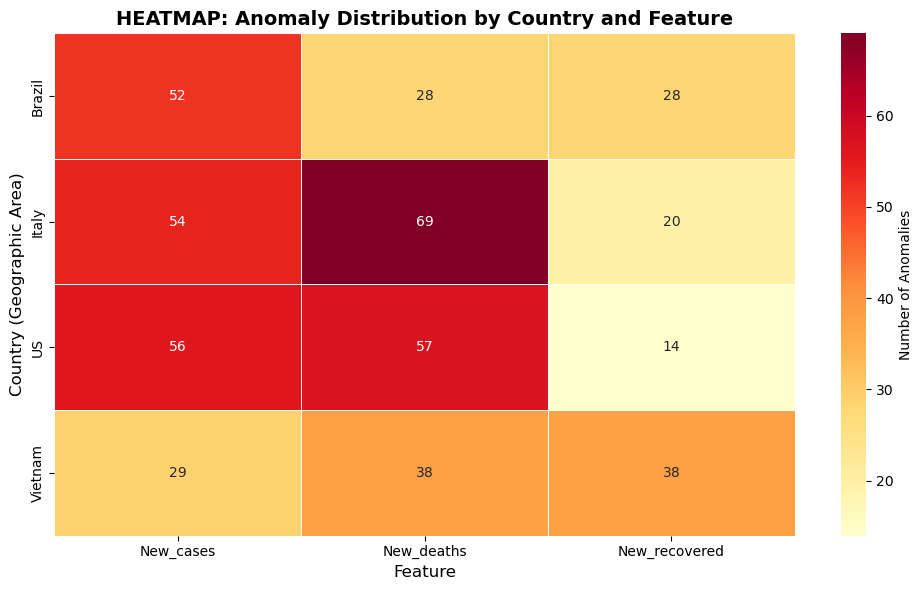

Feature,New_cases,New_deaths,New_recovered
Country,,,
Brazil,52,28,28
Italy,54,69,20
US,56,57,14
Vietnam,29,38,38


In [26]:
# Tạo Pivot Table
pivot_heat = df_heatmap.pivot(index='Country', columns='Feature', values='Anomalies')

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_heat, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5, 
            cbar_kws={'label': 'Number of Anomalies'})

plt.title('HEATMAP: Anomaly Distribution by Country and Feature', fontsize=14, fontweight='bold')
plt.ylabel('Country (Geographic Area)', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

display(pivot_heat)

Một vài nhận xét rút ra cho các kết quả trên như sau: 
- **Biến số nhiễu và biến động nhất là Số ca tử vong (Deaths) và Số ca mắc (Cases)**
    + Nếu cộng gộp trên toàn bộ 4 quốc gia, **Số ca tử vong (192 điểm)** và **Số ca mắc mới (191 điểm)** là hai nhóm dữ liệu chứa nhiều bất thường nhất, với mức độ giật cục gần như tương đương nhau.
    + Nguyên nhân thực tế: Đây là hai chỉ số mang tính sống còn, chịu áp lực báo cáo công khai từng ngày. Chính vì sự gấp gáp này, chúng cực kỳ dễ bị tác động bởi các lỗi hành chính: trễ nhịp cuối tuần, nghẽn mạng lưới xét nghiệm, hoặc các đợt thanh tra dẫn đến việc cộng dồn/trừ đi hàng ngàn ca vào một ngày duy nhất. Điển hình là Ý với ghi nhận số điểm dị thường về tử vong cao kỷ lục (69 điểm), phản ánh hoàn toàn chính xác bối cảnh lịch sử thực tế ở giai đoạn đầu năm 2020, khi hệ thống y tế Ý vỡ trận, việc xét nghiệm và đếm số ca tử vong bị dồn ứ nghiêm trọng.
- **Biến số ổn định nhất là Số ca khỏi bệnh (Recovered)**
    + Trái ngược với sự hỗn loạn của hai biến trên, **Số ca khỏi bệnh** có tổng lượng dị thường thấp nhất (chỉ 100 điểm), đặc biệt là ở Mỹ (14 điểm) và Ý (20 điểm).
    + Nguyên nhân cho sự ổn định này không phải vì hệ thống đếm tốt hơn, mà thường là do là nó lại ít được quan tâm hơn. Trong thời kỳ đỉnh dịch, các bệnh viện dồn toàn lực vào cấp cứu và đếm ca tử vong/ca lây nhiễm, dẫn đến dữ liệu bệnh nhân khỏi bệnh thường không được cập nhật sát sao mỗi ngày. Vậy nên kết quả của biến số này thường được tính từ các thuật toán y tế tự động ước tính (ví dụ: sau 14 ngày không triệu chứng thì tự động tính là khỏi), khiến đường xu hướng của nó trở nên mượt mà một cách thiếu tự nhiên. 
- Dù vậy, **một hiện tượng ngoại lệ đã xảy ra ở Việt Nam**. Việt Nam là quốc gia duy nhất đi ngược lại xu hướng toàn cầu trong bảng này với **điểm dị thường ở số ca khỏi (38) và tử vong (38) lại cao hơn số ca mắc (29)**. Điều này có thể phản ánh sự thành công của chiến lược "Zero Covid" được áp dụng ở giai đoạn 2020. Vì mức nền số ca bệnh gần như bằng 0, nên chỉ cần một sự kiện nhỏ như một đợt công bố vài chục bệnh nhân xuất viện cùng lúc, hoặc một vài ca tử vong hiếm hoi đợt dịch Đà Nẵng cũng có thể ngay lập tức tạo một cú sốc khổng lồ về mặt tỷ lệ đối với thuật toán Isolation Forest.

### 2.6. Đối chiếu dị thường với sự kiện thực tế

Phần này sẽ kiểm tra xem các điểm dị thường do thuật toán tìm ra là do bùng dịch thật hay chỉ là lỗi dồn báo cáo y tế, bằng cách trích xuất top 5 ngày có số ca mắc mới cao nhất từ tập hợp các điểm dị thường, từ đó đối chiếu với lịch sử báo chí để phân loại nguyên nhân thành 3 nhóm:
- **(A) Lỗi nhập liệu/Dồn báo cáo**: Thường rơi vào đầu tuần hoặc sau ngày lễ.
- **(B) Sự kiện lây nhiễm thực tế**: Đỉnh điểm của các làn sóng dịch.
- **(C) Thay đổi chính sách**: Mở rộng tiêu chí xét nghiệm.

In [29]:
top_spikes = df_anomalies_only.sort_values(by='New_cases', ascending=False).head().copy()

if 'DayOfWeek' not in top_spikes.columns:
    top_spikes['DayOfWeek'] = top_spikes['Date'].dt.day_name()

analysis_table = top_spikes[['Date', 'DayOfWeek', 'New_cases', 'Vote_Count']].copy()

analysis_table['Date'] = analysis_table['Date'].dt.strftime('%Y-%m-%d')

display(analysis_table)

,Date,DayOfWeek,New_cases,Vote_Count
716,2020-07-16,Thursday,77362.0,1
722,2020-07-22,Wednesday,71305.0,1
730,2020-07-30,Thursday,67779.0,1
725,2020-07-25,Saturday,66454.0,1
745,2020-08-14,Friday,64601.0,1


Đây là bản kết quả đầy đủ kèm minh chứng lịch sử (có nguồn để đối chiếu). 

In [30]:
root_cause_data = {
    'Date': ['2020-07-16', '2020-07-22', '2020-07-30', '2020-07-25', '2020-08-14'],
    'DayOfWeek': ['Thursday', 'Wednesday', 'Thursday', 'Saturday', 'Friday'],
    'New_cases': [77362, 71305, 67779, 66454, 64601],
    'Vote_Count': [1, 1, 1, 1, 1],
    'Root_Cause_Category': [
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế',
        '(B) Bùng phát thực tế',
        '(A) Lỗi dồn báo cáo'
    ],
    'Real_World_Event_Evidence': [
        'Mỹ phá kỷ lục lây nhiễm toàn cầu trong 1 ngày. Đây là đỉnh điểm của Làn sóng mùa hè (Sun Belt Surge) tại Florida, Texas và California. Nguồn: https://www.voanews.com/a/covid-19-pandemic_us-sets-new-daily-record-coronavirus-infections/6197534.html',
        'Sự kiện lây nhiễm lịch sử: Bang California chính thức vượt mặt New York để trở thành tâm dịch lớn nhất nước Mỹ. Nguồn: https://www.courthousenews.com/california-surpasses-new-york-with-most-covid-cases-in-us/',
        'Làn sóng mùa hè (Summer Surge) duy trì ở mức đỉnh. Số lượng mẫu xét nghiệm quá lớn khiến hàng loạt phòng thí nghiệm tại Mỹ rơi vào tình trạng quá tải. Nguồn: https://www.cbc.ca/news/world/coronavirus-july-22-covid-19-1.5658410',
        'Dù là ngày nghỉ cuối tuần nhưng số ca vẫn cao ngất ngưởng, chứng tỏ năng lực xét nghiệm đang phải chạy tối đa công suất do dịch lây lan quá mạnh tại miền Nam nước Mỹ. Nguồn: https://www.cbc.ca/news/world/coronavirus-july-22-covid-19-1.5658410',
        'Sự cố công nghệ y tế: Hệ thống báo cáo CalREDIE của bang California bị sập do lỗi chứng chỉ và máy chủ, dẫn đến tồn đọng gần 300.000 kết quả xét nghiệm. Sau khi hệ thống được khắc phục, số ca bệnh được xả kho gây dồn cục trên dữ liệu. Nguồn: https://www.capradio.org/articles/2020/08/07/california-grapples-with-covid-19-data-error-resulting-in-undercounts-but-official-says-cases-still-on-decline/'
    ]
}

df_root_cause_analysis = pd.DataFrame(root_cause_data)

pd.set_option('display.max_colwidth', None)

display(df_root_cause_analysis)

,Date,DayOfWeek,New_cases,Vote_Count,Root_Cause_Category,Real_World_Event_Evidence
0,2020-07-16,Thursday,77362,1,(B) Bùng phát thực tế,"Mỹ phá kỷ lục lây nhiễm toàn cầu trong 1 ngày. Đây là đỉnh điểm của Làn sóng mùa hè (Sun Belt Surge) tại Florida, Texas và California. Nguồn: https://www.voanews.com/a/covid-19-pandemic_us-sets-new-daily-record-coronavirus-infections/6197534.html"
1,2020-07-22,Wednesday,71305,1,(B) Bùng phát thực tế,Sự kiện lây nhiễm lịch sử: Bang California chính thức vượt mặt New York để trở thành tâm dịch lớn nhất nước Mỹ. Nguồn: https://www.courthousenews.com/california-surpasses-new-york-with-most-covid-cases-in-us/
2,2020-07-30,Thursday,67779,1,(B) Bùng phát thực tế,Làn sóng mùa hè (Summer Surge) duy trì ở mức đỉnh. Số lượng mẫu xét nghiệm quá lớn khiến hàng loạt phòng thí nghiệm tại Mỹ rơi vào tình trạng quá tải. Nguồn: https://www.cbc.ca/news/world/coronavirus-july-22-covid-19-1.5658410
3,2020-07-25,Saturday,66454,1,(B) Bùng phát thực tế,"Dù là ngày nghỉ cuối tuần nhưng số ca vẫn cao ngất ngưởng, chứng tỏ năng lực xét nghiệm đang phải chạy tối đa công suất do dịch lây lan quá mạnh tại miền Nam nước Mỹ. Nguồn: https://www.cbc.ca/news/world/coronavirus-july-22-covid-19-1.5658410"
4,2020-08-14,Friday,64601,1,(A) Lỗi dồn báo cáo,"Sự cố công nghệ y tế: Hệ thống báo cáo CalREDIE của bang California bị sập do lỗi chứng chỉ và máy chủ, dẫn đến tồn đọng gần 300.000 kết quả xét nghiệm. Sau khi hệ thống được khắc phục, số ca bệnh được xả kho gây dồn cục trên dữ liệu. Nguồn: https://www.capradio.org/articles/2020/08/07/california-grapples-with-covid-19-data-error-resulting-in-undercounts-but-official-says-cases-still-on-decline/"
